<a href="https://colab.research.google.com/github/iqlore-collab/A-B-Testing-Chi-Squer/blob/main/Statistical_Analysis_of_Web_Variants_(CTR_%26_Chi_Square_Test).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🧾 Introduction

In this notebook, we analyze the performance of multiple website variants using an A/B/n testing approach. The goal of the analysis is to evaluate and compare click-through rates (CTR) across different versions of a webpage in order to determine whether any variant performs significantly better than the current version.

We use click and visit data collected from different user interactions and compute CTR for each variant. To assess whether observed differences are statistically significant, we apply the Chi-Square test and perform pairwise comparisons with Bonferroni correction to control for multiple testing.

The final objective is to support data-driven decision-making by identifying whether a new variant should replace the current version or if the existing version should be retained.

Variants

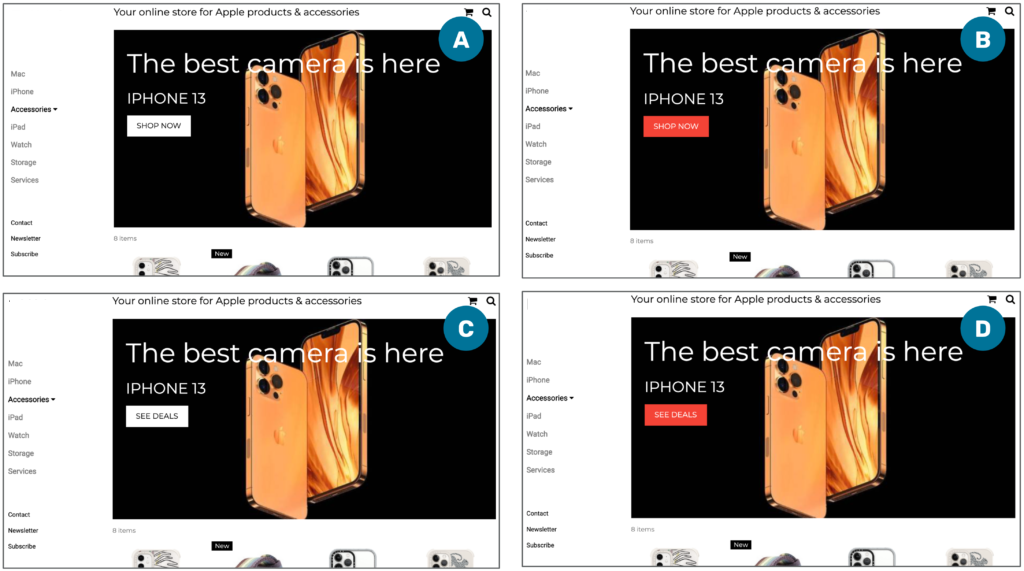

In [114]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns

# Hypothesis testing: Chi-Square Test within the ITRIEL case study

In this notebook we perform a chi-square test with the data from the Itriel case study, applying a post-hoc correction to perform pairwise tests and find the true winner.

## 1.&nbsp;Stating the Null Hypothesis and the Alternative Hypothesis.

Null Hypothesis H0: All versions have the same CTR.

Alternative Hypothesis HA: There is a difference in the CTR for the different versions.

## 2.&nbsp; Selecting an appropriate significance level alpha ($\alpha$).

It was decided that a relatively high alpha was acceptable in this case

In [115]:
alpha = 0.05

## 3.&nbsp; Collecting data that is random and independent

The important pieces of information (clicks on each element of interest & visits on each page) are scattered around. Let's collect them. Where are the .csv files? 🥸

In [117]:
import pandas as pd

def load_csv_from_gdrive(url, name):
    try:
        file_id = url.split('/')[-2]
        path = f"https://drive.google.com/uc?export=download&id={file_id}"

        df = pd.read_csv(path)

        print(f"✅ {name} loaded successfully")
        print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

        return df

    except Exception as e:
        print(f"❌ Failed to load {name}")
        print(f"   Error: {e}\n")
        return None


# Load datasets
sample_a = load_csv_from_gdrive(
    "https://drive.google.com/file/d/1h0_81KvHpBHlrkf9CfNx1zhfNT_g438z/view?usp=drive_link",
    "sample_a"
)

sample_b = load_csv_from_gdrive(
    "https://drive.google.com/file/d/1e1pCgizYyTPyQeg_F2l9-f2lbVRi5CYC/view?usp=drive_link",
    "sample_b"
)

sample_c = load_csv_from_gdrive(
    "https://drive.google.com/file/d/1Ve1s2rSjZVar_YXhndErLQcPx2jdyTh4/view?usp=drive_link",
    "sample_c"
)

sample_d = load_csv_from_gdrive(
    "https://drive.google.com/file/d/1aoD9P5MDcgnLqcVoFrl3CKSUPIwa5iQe/view?usp=drive_link",
    "sample_d"
)

✅ sample_a loaded successfully
   Shape: 57 rows × 6 columns

✅ sample_b loaded successfully
   Shape: 57 rows × 6 columns

✅ sample_c loaded successfully
   Shape: 57 rows × 6 columns

✅ sample_d loaded successfully
   Shape: 57 rows × 6 columns



Finding the relevant data

In [118]:
sample_a

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
0,48,h1,ITRIEL,269,True,Homepage Version A - white SHOP NOW • http...
1,25,div,mySidebar,309,True,created 2021-09-14 • 14 days 0 hours 34 mi...
2,4,a,Mac,279,True,NaN
3,69,a,iPhone,246,True,NaN
4,105,a,Accessories,1235,True,NaN
5,36,a,Chargers & Cables,1261,False,NaN
6,99,a,iPhone Accessories,1226,False,NaN
7,68,a,Watch Accessories,1261,False,NaN
8,13,a,Mac Accessories,1308,False,NaN
9,15,a,AirTag,206,False,NaN


Clicks are stored in row Shop NOw/SeeDeals (column Name), extracting number of clicks from column No.Clicks

In [119]:
# manually
a_clicks = sample_a.loc[sample_a['Name'] == 'SHOP NOW', 'No. clicks'].values[0]

In [120]:
# using a for loop to get click of a 4 samples at once
clicks=[]
versions=['SHOP NOW','SEE DEALS']
for df in [sample_a, sample_b, sample_c, sample_d]:
    clicks_1 = df.loc[df['Name'] .isin(versions), 'No. clicks'].iloc[0]
    clicks.append(clicks_1)
clicks

[np.int64(512), np.int64(281), np.int64(527), np.int64(193)]

Number of visits

In [121]:
sample_a.loc[1, 'Snapshot information']

'created 2021-09-14   •   14 days 0 hours 34 mins   •   25326 visits, 23174 clicks'

In [122]:
# automatically using regex, manually if completly fine, too!
visits = []
for df in (sample_a, sample_b, sample_c, sample_d):
  # Extracts the numeric count from a string containing one or more digits followed by the word "visits."
    val = df.loc[df['Name'] == 'mySidebar', 'Snapshot information'].str.extract(r'(\d+)\s+visits')[0]
    visits.append(int(val.item()))

visits

[25326, 24747, 24876, 25233]

Seting up the dataframe/contingency table

In [123]:
observed_results = pd.DataFrame(
    [clicks, visits], columns=["A", "B", "C","D"], index=["Clicks", "Visits"]
)
observed_results.loc['No_clicks'] = observed_results.loc['Visits'] - observed_results.loc['Clicks']
observed_results

,A,B,C,D
Clicks,512,281,527,193
Visits,25326,24747,24876,25233
No_clicks,24814,24466,24349,25040


In [124]:
data = observed_results.loc[['Clicks', 'No_clicks']]
data

,A,B,C,D
Clicks,512,281,527,193
No_clicks,24814,24466,24349,25040


## 4.&nbsp; Calculating the Chi-Square Test result

In [125]:
chisq, pvalue, df, expected = stats.chi2_contingency(data)

In [126]:
chisq

np.float64(224.01877488058412)

In [127]:
pvalue

np.float64(2.7161216607868712e-48)

## 5.&nbsp; Interpreting the test result

The p-value is smaller than alpha.
  We reject the null hypothesis. There is a sufficient evidence to suggest
  at least one of the web pages has a significantly different click through rate
  compared to the others. Identify the better performing website with post-hoc test.

In [128]:
def interpret_chi_square(chisq, pvalue, alpha=0.05):

    print(f"Chi-square statistic: {chisq:.4f}")
    print(f"p-value: {pvalue:.6f}\n")

    if pvalue < alpha:
        print(f"The p-value is smaller than alpha ({alpha}).")
        print("We reject the null hypothesis.")
        print(
            "There is sufficient evidence to suggest that at least one of the web pages "
            "has a significantly different click-through rate compared to the others."
        )

    else:
        print(f"The p-value is greater than alpha ({alpha}).")
        print("We fail to reject the null hypothesis.")
        print(
            "There is not sufficient evidence to suggest a difference in click-through rates."
        )

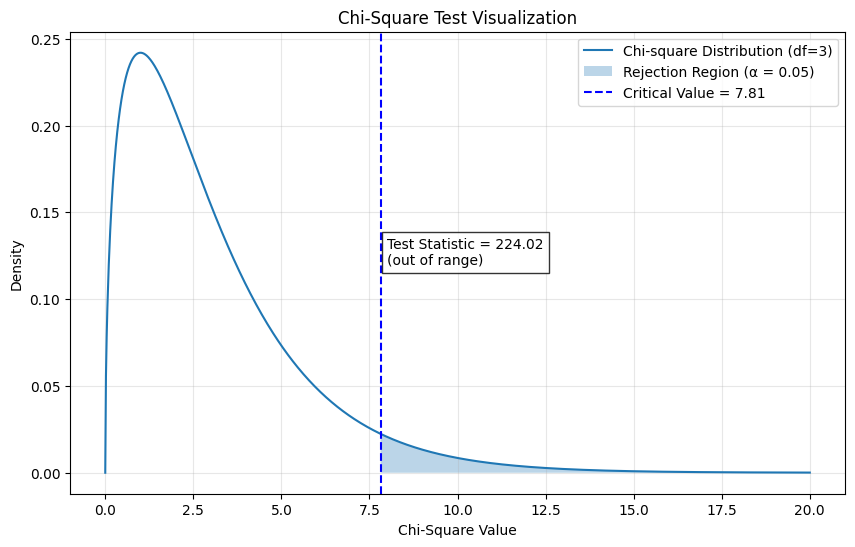

In [136]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Parametry
df = 3                 # stopnie swobody
alpha = 0.05           # poziom istotności
test_stat = 224.02     # statystyka testowa

# Zakres osi X
x = np.linspace(0, 20, 1000)

# Rozkład chi-kwadrat
y = chi2.pdf(x, df)

# Wartość krytyczna
critical_value = chi2.ppf(1 - alpha, df)

# Wykres
plt.figure(figsize=(10, 6))
plt.plot(x, y, label=f'Chi-square Distribution (df={df})')

# Obszar odrzucenia
x_fill = np.linspace(critical_value, 20, 300)
plt.fill_between(x_fill, chi2.pdf(x_fill, df), alpha=0.3, label='Rejection Region (α = 0.05)')

# Linia wartości krytycznej
plt.axvline(critical_value, color='blue', linestyle='--', label=f'Critical Value = {critical_value:.2f}')

# Adnotacja statystyki testowej
plt.text(8, 0.12, f'Test Statistic = {test_stat:.2f}\n(out of range)',
         bbox=dict(facecolor='white', alpha=0.8))

# Opisy
plt.title('Chi-Square Test Visualization')
plt.xlabel('Chi-Square Value')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [129]:
interpret_chi_square(chisq, pvalue)

Chi-square statistic: 224.0188
p-value: 0.000000

The p-value is smaller than alpha (0.05).
We reject the null hypothesis.
There is sufficient evidence to suggest that at least one of the web pages has a significantly different click-through rate compared to the others.


In [130]:
ctr = observed_results.loc["Clicks"] / observed_results.loc["Visits"]
print(ctr)

A    0.020216
B    0.011355
C    0.021185
D    0.007649
dtype: float64


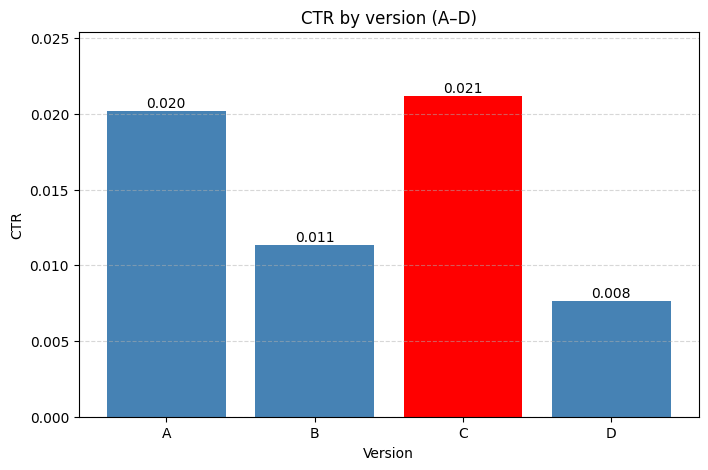

In [131]:
import matplotlib.pyplot as plt

ctr = observed_results.loc["Clicks"] / observed_results.loc["Visits"]

# znajdź max
max_idx = ctr.idxmax()

# kolory
colors = ["red" if i == max_idx else "steelblue" for i in ctr.index]

plt.figure(figsize=(8, 5))
bars = plt.bar(ctr.index, ctr.values, color=colors)

plt.title("CTR by version (A–D)")
plt.xlabel("Version")
plt.ylabel("CTR")

plt.ylim(0, ctr.max() * 1.2)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# podpisy wartości
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.show()

## Deciding who's the winner?

Click-through rate (CTR) for the homepage. Amount of clicks on the button divided by the total visits to the page. Selected as a measure of the initial ability of a website element to lead users to interact with it.

In [132]:
ctr = observed_results.loc["Clicks"] / observed_results.loc["Visits"]

winner = ctr.idxmax()
winner_value = ctr.max()

print("CTR per variant:")
print(ctr)
print("\n🏆 Winner:", winner)
print(f"CTR = {winner_value:.4f}")

CTR per variant:
A    0.020216
B    0.011355
C    0.021185
D    0.007649
dtype: float64

🏆 Winner: C
CTR = 0.0212


But statistical significance matters

In [133]:
import itertools


combos = list(itertools.combinations(data, 2))

for combo in combos:
  print(f"{combo[0]} vs {combo[1]}", end=': ')
  res = stats.chi2_contingency(data.loc[:,list(combo)])
  if res.pvalue < alpha / len(combos):
    print(f"Significant. p = {res.pvalue:.3f}")
  else:
    print(f"NOT significant. p = {res.pvalue:.3f}")


A vs B: Significant. p = 0.000
A vs C: NOT significant. p = 0.465
A vs D: Significant. p = 0.000
B vs C: Significant. p = 0.000
B vs D: Significant. p = 0.000
C vs D: Significant. p = 0.000


Who is the business winner, given that variant A is the current version and variant C would need to be implemented?

In [134]:
import itertools
from scipy import stats

# CTR
ctr = observed_results.loc["Clicks"] / observed_results.loc["Visits"]

print("CTR per variant:")
print(ctr)

# pairwise tests
alpha = 0.05
combos = list(itertools.combinations(data, 2))

losses = {col: 0 for col in data.columns}
not_sig = []

print("\nPairwise comparisons:\n")

for combo in combos:
    print(f"{combo[0]} vs {combo[1]}", end=': ')

    res = stats.chi2_contingency(data.loc[:, list(combo)])

    if res.pvalue < alpha / len(combos):
        print(f"Significant. p = {res.pvalue:.3f}")

        # kto przegrywa
        if ctr[combo[0]] > ctr[combo[1]]:
            losses[combo[1]] += 1
        else:
            losses[combo[0]] += 1
    else:
        print(f"NOT significant. p = {res.pvalue:.3f}")
        not_sig.append(combo)

# decyzja
max_ctr = ctr.max()
top = ctr[ctr >= max_ctr * 0.95].index.tolist()
top_group = [t for t in top if losses[t] == 0]

print("\n🏆 Final decision:")

if len(top_group) == 1:
    print(f"Clear winner: {top_group[0]}")
else:
    print("No clear winner.")
    print(f"Variants {', '.join(top_group)} perform similarly (no statistically significant difference).")

CTR per variant:
A    0.020216
B    0.011355
C    0.021185
D    0.007649
dtype: float64

Pairwise comparisons:

A vs B: Significant. p = 0.000
A vs C: NOT significant. p = 0.465
A vs D: Significant. p = 0.000
B vs C: Significant. p = 0.000
B vs D: Significant. p = 0.000
C vs D: Significant. p = 0.000

🏆 Final decision:
No clear winner.
Variants A, C perform similarly (no statistically significant difference).


We can also stick with the current variant A. No change needed.

Additional Data:

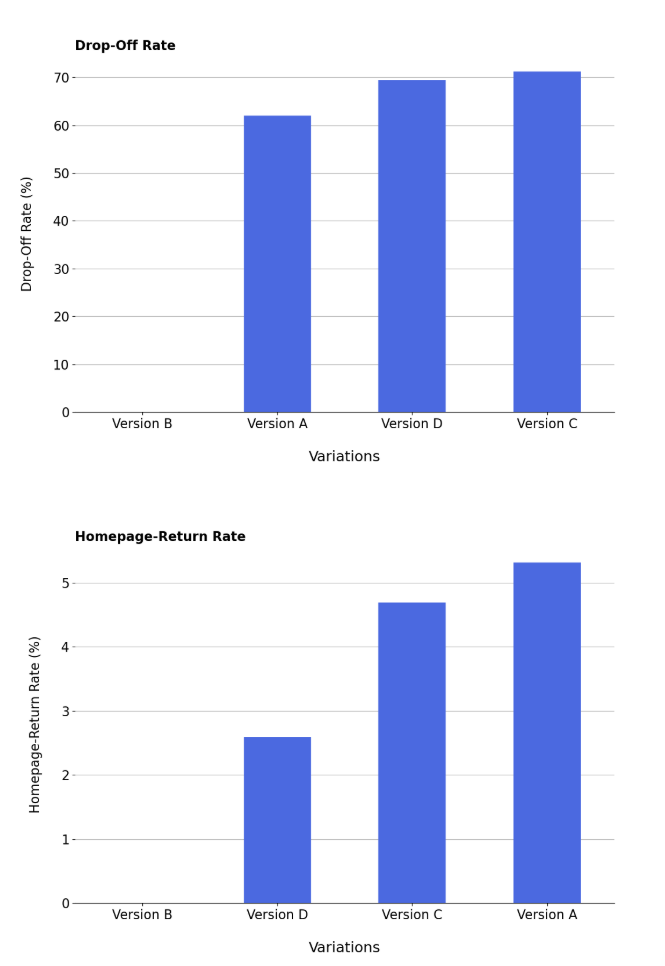

🔴 Variant C

may have higher CTR ↑
but:
higher drop-off ↑ ❌ (negative signal)
user frustration / mismatch in intent

👉 This means: “users click, but quickly leave.”

🟢 Variant A

stable CTR
lower drop-off ✔
higher homepage return rate ✔

👉 This means:

more “safe” UX
users return instead of abandoning the page
better navigation / better intent matching

Although variant C may show competitive CTR, it also has a higher drop-off rate, indicating weaker user retention after click.
Variant A shows a higher homepage return rate and lower drop-off, suggesting better overall user experience.
Therefore, variant A should be preferred for implementation.